In [1]:
using Distributed
addprocs(25)
@everywhere include("1_timed_resk.jl")

In [5]:
A, tim = @timed rangeexp_ray_inf(200,300,25;x_max_burnin=5,x_max_exp=500,data_to_generate="F",capacity=100,prolif_rate=2,mut_rate=0.05,migr_rate=0.05,sel_coef=0.005,weightfitn=false,condsel=true,fixed_mate=true,multiproc=true)
tim

Running 25 replicates on [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26] processes


15.6028397

In [23]:
A["fitn"][:,:,22]

500×500 Matrix{Float32}:
   1.0    0.999847    0.999639  …    1.00651     1.00525     1.00567
   1.0    0.99983     0.999756       1.00283     1.00133     1.00128
   1.0    0.999706    0.999563       0.998387    0.999813    0.999506
   1.0    0.999788    0.999764       1.00283     1.00229     1.00163
   1.0    0.999845    0.999515       1.0011      1.0033      1.0033
 NaN    NaN         NaN         …    1.00472     1.0053      1.00598
 NaN    NaN         NaN              1.00258     1.00026     1.00165
 NaN    NaN         NaN              0.983772    0.983488    0.986828
 NaN    NaN         NaN              0.996983    0.995507    0.996137
 NaN    NaN         NaN              0.996517    0.997187    0.99793
   ⋮                            ⋱                          
 NaN    NaN         NaN            NaN         NaN         NaN
 NaN    NaN         NaN            NaN         NaN         NaN
 NaN    NaN         NaN            NaN         NaN         NaN
 NaN    NaN         NaN           

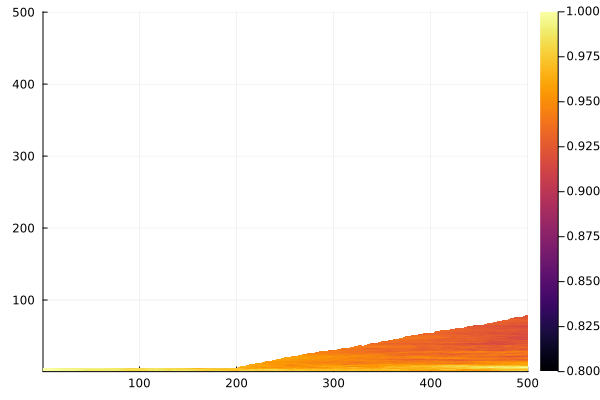

In [15]:
using Plots
heatmap(A["fitn"][:,:,21],clim=(0.8,1.0))

In [5]:
@show A["fitn"][:,end,1]

(A["fitn"])[:, end, 1] = Float32[1.0049111, 1.0031276, 1.0067309, 1.0084358, 1.0104117, 1.0084698, 0.9955332, 0.99266803, 0.9945496, 0.9889173, 0.9865552, 0.986765, 0.9846171, 0.9751167, 0.96225196, 0.96779287, 0.9701219, 0.97598284, 0.97292006, 0.9674113, 0.96315885, 0.9702031, 0.96507555, 0.96414316, 0.96114695, 0.9552527, 0.9605193, 0.96138316, 0.95641357, 0.95892125, 0.95586634, 0.9489535, 0.9493486, 0.94604623, 0.94738346, 0.9413892, 0.9420695, 0.93954575, 0.93988466, 0.94346845, 0.9374066, 0.93386936, 0.9308707, 0.93638474, 0.94287187, 0.94172615, 0.9383801, 0.93588084, 0.9340709, 0.9365782, 0.9358941, 0.94273734, 0.94109, 0.94353265, 0.93880963, 0.9323282, 0.9198504, 0.9214709, 0.9289268, 0.92436785, 0.9247366, 0.921821, 0.9223769, 0.9215162, 0.9256383, 0.929578, 0.93291014, 0.92859197, 0.93001837, 0.932116, 0.9316257, 0.93140376, 0.93347174, 0.93415815, 0.93776774, 0.93875706, 0.9386586, 0.93902093, 0.9393392, 0.93892485, 0.9388335, 0.93218356, NaN, NaN, NaN, NaN, NaN, NaN, NaN

500-element Vector{Float32}:
   1.0049111
   1.0031276
   1.0067309
   1.0084358
   1.0104117
   1.0084698
   0.9955332
   0.99266803
   0.9945496
   0.9889173
   ⋮
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN

In [13]:
[findlast(x -> !isnan(x), A["fitn"][:,:,j]) for j in 1:25]

25-element Vector{CartesianIndex{2}}:
 CartesianIndex(82, 500)
 CartesianIndex(77, 500)
 CartesianIndex(78, 500)
 CartesianIndex(83, 500)
 CartesianIndex(84, 500)
 CartesianIndex(79, 500)
 CartesianIndex(79, 500)
 CartesianIndex(82, 500)
 CartesianIndex(78, 500)
 CartesianIndex(78, 500)
 ⋮
 CartesianIndex(83, 500)
 CartesianIndex(80, 500)
 CartesianIndex(77, 500)
 CartesianIndex(78, 500)
 CartesianIndex(83, 500)
 CartesianIndex(82, 500)
 CartesianIndex(79, 500)
 CartesianIndex(89, 500)
 CartesianIndex(85, 500)

In [14]:
indicess = [findlast(x -> !isnan(x), A["fitn"][:,:,j]) for j in 1:25]
last_valid_index = mean(ci.I[1] for ci in indicess)

80.36

In [6]:
using Statistics

avg = mapslices(x -> mean(skipmissing(x)), A["fitn"]; dims=3)[:,:,1]

500×500 Matrix{Float32}:
   1.0    0.999794    0.999544  …    0.990226    0.989966    0.989637
   1.0    0.999815    0.999618       0.988507    0.988564    0.988906
   1.0    0.999823    0.999632       0.989894    0.989978    0.98997
   1.0    0.99979     0.999579       0.989957    0.990458    0.990554
   1.0    0.999817    0.999659       0.990338    0.990284    0.990556
 NaN    NaN         NaN         …    0.987287    0.987234    0.987303
 NaN    NaN         NaN              0.986331    0.986294    0.986761
 NaN    NaN         NaN              0.983207    0.983549    0.983528
 NaN    NaN         NaN              0.981717    0.981721    0.981317
 NaN    NaN         NaN              0.977975    0.978054    0.978383
   ⋮                            ⋱                          
 NaN    NaN         NaN            NaN         NaN         NaN
 NaN    NaN         NaN            NaN         NaN         NaN
 NaN    NaN         NaN            NaN         NaN         NaN
 NaN    NaN         NaN    

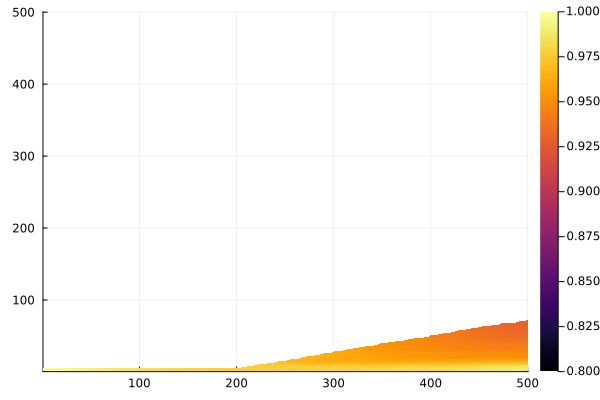

In [8]:
using Plots
heatmap(avg,clim=(0.8,1.0))

In [9]:
avg[findlast(x -> !isnan(x), avg)]

0.92875975f0

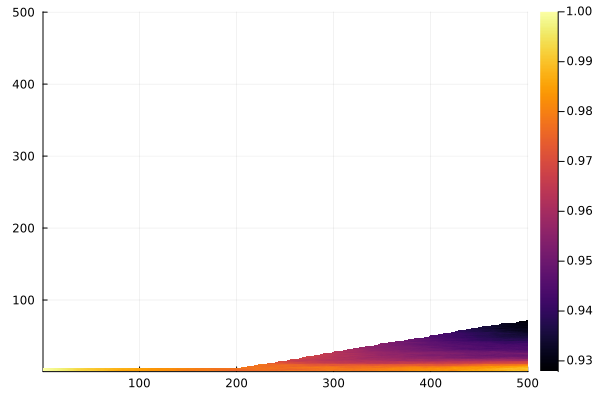

In [10]:
heatmap(avg)

---

In [1]:
using Distributed
addprocs(10)
@everywhere include("1_timed_resk.jl")

In [4]:
A, tim = @timed rangeexp_ray_inf(200,500,10;x_max_burnin=5,x_max_exp=500,data_to_generate="FP",capacity=100,prolif_rate=2,mut_rate=0.05,migr_rate=0.05,sel_coef=0.005,weightfitn=false,condsel=true,fixed_mate=true,multiproc=true)
tim

Running 10 replicates on [2, 3, 4, 5, 6, 7, 8, 9, 10, 11] processes


16.4384224

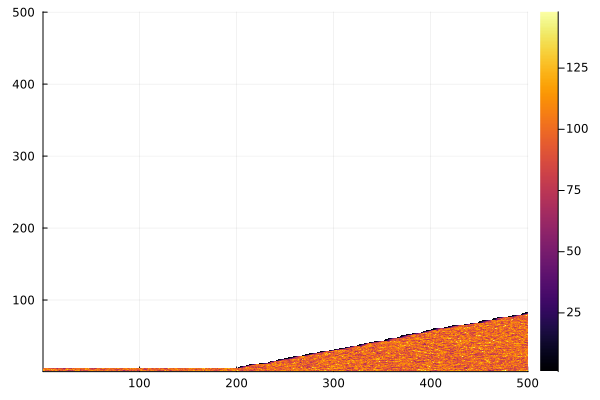

In [4]:
using Plots
heatmap(A["pops"][:,:,1])

---

In [1]:
using Distributed
addprocs(10)
@everywhere include("1_timed_resk_opt.jl")

In [1]:
include("1_timed_resk_opt.jl")

rangeexp_ray_inf (generic function with 4 methods)

In [3]:
A, tim = @timed rangeexp_ray_inf(200,500,10)
tim

Running 10 replicates on [2, 3, 4, 5, 6, 7, 8, 9, 10, 11] processes


15.0141159

In [4]:
A.pops

500×12500 Matrix{Float32}:
 112.0  107.0  107.0   98.0   94.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
  77.0   87.0  103.0   93.0   90.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 103.0   94.0   97.0  110.0  122.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
  94.0   91.0   94.0   85.0   98.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
  96.0  103.0  113.0  106.0  102.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
   5.0   13.0   21.0   34.0   41.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
   0.0    0.0    0.0    0.0    4.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
   0.0    0.0    0.0    0.0    0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
   0.0    0.0    0.0    0.0    0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
   0.0    0.0    0.0    0.0    0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
   ⋮                                ⋱            ⋮                   
   0.0    0.0    0.0    0.0    0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
   0.0    0.0    0.0    0.0    0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
   0.0    0.0    0.0    0.0

---

In [1]:
using Distributed
n_re = 10
addprocs(n_re)
@everywhere include("1_timed_resk_opt2.jl")

In [4]:
# Run replicates
results = Vector{NamedTuple{(:pops, :fitness), Tuple{Array{typ_float}, Array{typ_float}}}}(undef, n_re)
A, tim = @timed pmap(rangeexp_ray_inf, 1:n_re)
wo = workers()
println("Running $n_re replicates on $wo processes")
tim

Running 10 replicates on [2, 3, 4, 5, 6, 7, 8, 9, 10, 11] processes


24.2303275

In [5]:
A[1].fitness

500×2000 Matrix{Float32}:
 0.999314  0.998685  0.998388  …  1.54458  1.53762  1.54412  1.54042
 0.9996    0.999044  0.998529     1.55143  1.55295  1.55303  1.55017
 0.999588  0.999316  0.998565     1.5691   1.56609  1.5695   1.57455
 0.999477  0.998778  0.998604     1.56759  1.57103  1.57271  1.57462
 0.999546  0.99927   0.998495     1.58227  1.58885  1.58454  1.57809
 0.0       0.0       0.0       …  1.57219  1.57269  1.56443  1.56436
 0.0       0.0       0.0          1.57046  1.56909  1.56885  1.57325
 0.0       0.0       0.0          1.56683  1.56018  1.56482  1.55897
 0.0       0.0       0.0          1.61224  1.61209  1.62696  1.61867
 0.0       0.0       0.0          1.64793  1.65256  1.64633  1.63627
 ⋮                             ⋱                             
 0.0       0.0       0.0          0.0      0.0      0.0      0.0
 0.0       0.0       0.0          0.0      0.0      0.0      0.0
 0.0       0.0       0.0          0.0      0.0      0.0      0.0
 0.0       0.0       0.0   

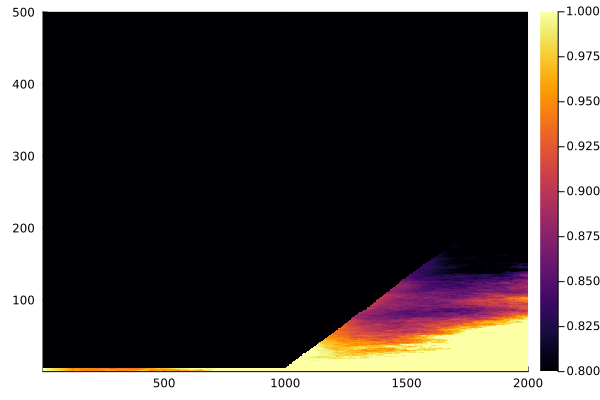

In [6]:
using Plots
heatmap(A[6].fitness,clim=(0.8,1.0))

In [ ]:
fits = getfield.(A, :fitness)

UndefVarError: UndefVarError: `fitness_arrays` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [14]:
stacked = cat(fits...; dims=ndims(fits[1]) + 1)

500×2000×10 Array{Float32, 3}:
[:, :, 1] =
 0.999314  0.998685  0.998388  …  1.54458  1.53762  1.54412  1.54042
 0.9996    0.999044  0.998529     1.55143  1.55295  1.55303  1.55017
 0.999588  0.999316  0.998565     1.5691   1.56609  1.5695   1.57455
 0.999477  0.998778  0.998604     1.56759  1.57103  1.57271  1.57462
 0.999546  0.99927   0.998495     1.58227  1.58885  1.58454  1.57809
 0.0       0.0       0.0       …  1.57219  1.57269  1.56443  1.56436
 0.0       0.0       0.0          1.57046  1.56909  1.56885  1.57325
 0.0       0.0       0.0          1.56683  1.56018  1.56482  1.55897
 0.0       0.0       0.0          1.61224  1.61209  1.62696  1.61867
 0.0       0.0       0.0          1.64793  1.65256  1.64633  1.63627
 ⋮                             ⋱                             
 0.0       0.0       0.0          0.0      0.0      0.0      0.0
 0.0       0.0       0.0          0.0      0.0      0.0      0.0
 0.0       0.0       0.0          0.0      0.0      0.0      0.0
 0.0      

In [16]:
avg_fitness = mean(stacked; dims=ndims(stacked))[:,:,end]

500×2000 Matrix{Float32}:
 0.999625  0.999129  0.998678  …  1.38206  1.38013  1.38329  1.38386
 0.999558  0.999148  0.998695     1.38844  1.38826  1.38727  1.38828
 0.999618  0.999213  0.998762     1.3982   1.39766  1.39847  1.4002
 0.999505  0.999116  0.998757     1.3988   1.39947  1.39952  1.40052
 0.999581  0.99924   0.998891     1.4051   1.40749  1.40811  1.40809
 0.0       0.0       0.0       …  1.40649  1.4081   1.40771  1.4081
 0.0       0.0       0.0          1.41201  1.41216  1.41271  1.41323
 0.0       0.0       0.0          1.40897  1.40909  1.4108   1.40969
 0.0       0.0       0.0          1.41889  1.41937  1.42     1.41836
 0.0       0.0       0.0          1.41876  1.42247  1.42127  1.42106
 ⋮                             ⋱                             
 0.0       0.0       0.0          0.0      0.0      0.0      0.0
 0.0       0.0       0.0          0.0      0.0      0.0      0.0
 0.0       0.0       0.0          0.0      0.0      0.0      0.0
 0.0       0.0       0.0     

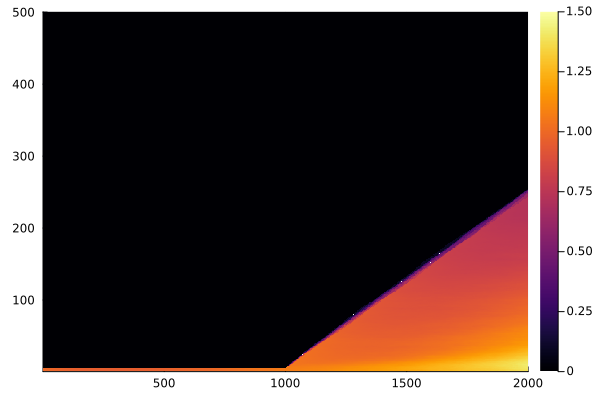

In [18]:
heatmap(avg_fitness,clim=(0,1.5))

---

In [1]:
include("1_timed_resk_opt2.jl")

rangeexp_ray_inf (generic function with 4 methods)

In [9]:
A1 = rangeexp_ray_inf(-1,1000,1000,1;weightfitn=false,condsel=true,premutate=true,fixed_mate=true,SS=true,verbose=false)

(fitness = Float32[0.99959207 0.99886066 … 1.3211322 1.315742; 0.99961966 0.9994333 … 1.3505702 1.3520484; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], pops = Float32[98.0 92.0 … 109.0 103.0; 92.0 97.0 … 86.0 91.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0])

In [ ]:
#= using Random
Random.seed!(123)

function heh(j)
    return rand(1)
end

A = heh(1) =#

1-element Vector{Float64}:
 0.521213795535383

In [5]:
A1.pops

500×200 Matrix{Float32}:
 107.0   92.0   98.0   88.0  92.0  …   94.0  108.0  124.0   94.0  100.0
  90.0   89.0  102.0  104.0  88.0     104.0   91.0   96.0   96.0  103.0
  99.0   75.0   95.0  109.0  96.0      86.0   98.0  103.0   85.0  105.0
  87.0   91.0   97.0   95.0  89.0      98.0  108.0  101.0  106.0  106.0
 100.0  103.0  102.0   85.0  89.0     102.0   99.0   78.0   86.0   91.0
   0.0    0.0    0.0    0.0   0.0  …  102.0  105.0   97.0  106.0   91.0
   0.0    0.0    0.0    0.0   0.0      96.0   92.0   89.0   94.0   92.0
   0.0    0.0    0.0    0.0   0.0     111.0  110.0  102.0  116.0  109.0
   0.0    0.0    0.0    0.0   0.0      88.0   87.0   91.0  101.0   89.0
   0.0    0.0    0.0    0.0   0.0     110.0   94.0  115.0   90.0  107.0
   ⋮                               ⋱    ⋮                         
   0.0    0.0    0.0    0.0   0.0       0.0    0.0    0.0    0.0    0.0
   0.0    0.0    0.0    0.0   0.0       0.0    0.0    0.0    0.0    0.0
   0.0    0.0    0.0    0.0   0.0       0.0 

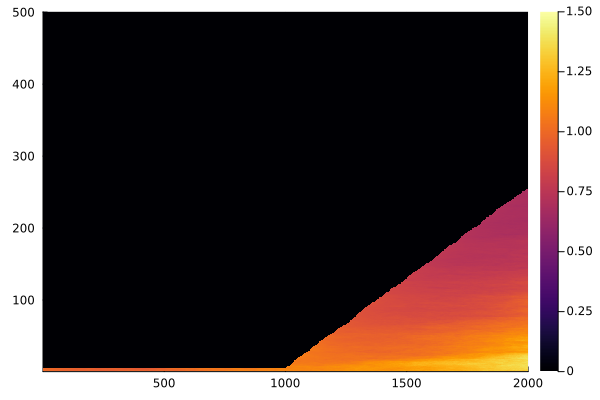

In [12]:
using Plots
heatmap(A1.fitness,clim=(0,1.5))

---

In [1]:
using Distributed
n_re = 2
addprocs(n_re)
@everywhere include("1_timed_resk_opt2.jl")

In [ ]:
# Run replicates
results = Vector{NamedTuple{(:pops, :fitness), Tuple{Array{typ_float}, Array{typ_float}}}}(undef, n_re)
A, tim = @timed pmap(x->rangeexp_ray_inf(), 1:n_re)
wo = workers()
println("Running $n_re replicates on $wo processes")
tim

Running 30 replicates on [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31] processes


6.8151434

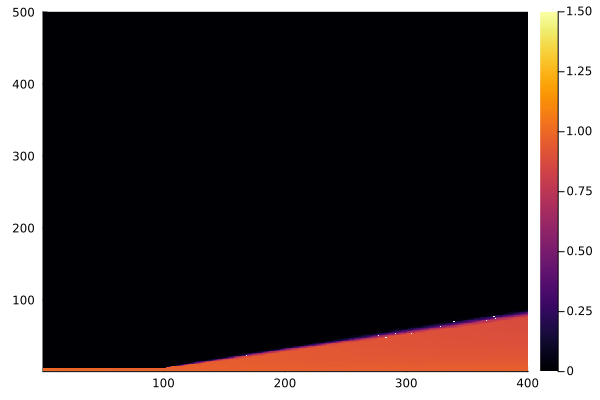

In [6]:
fits = getfield.(A, :fitness)
stacked = replace!(cat(fits...; dims=ndims(fits[1]) + 1),-1=>0)
avg_fitness = mean(stacked; dims=ndims(stacked))[:,:,end]
using Plots
heatmap(avg_fitness,clim=(0,1.5))

----

In [1]:
using Distributed
n_re = 30
addprocs(n_re)
@everywhere include("1_timed_resk_opt2.jl")

function dist_re(fnc=rangeexp_ray_inf;timed=false)
    wo = workers()
    println("Running $n_re replicates on $wo processes")
    if timed
        A,t = @timed pmap(x->fnc(), 1:n_re)
        println("Simulated in ",t," s")
        return A
    else
        return pmap(x->rangeexp_ray_inf(), 1:n_re)
    end
end

dist_re (generic function with 2 methods)

In [4]:
dist_re(;timed=true)

Running 30 replicates on [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31] processes
Simulated in 6.9630319 s


30-element Vector{@NamedTuple{fitness::Matrix{Float32}, pops::Matrix{Float32}}}:
 (fitness = [0.9995457 0.9994128 … 0.95376205 0.9542301; 0.9994248 0.9991852 … 0.9561521 0.95796126; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], pops = [99.0 102.0 … 82.0 102.0; 113.0 92.0 … 107.0 78.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0])
 (fitness = [0.9995214 0.9992687 … 0.948673 0.94852453; 0.9996635 0.9993984 … 0.94820327 0.94802207; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], pops = [94.0 82.0 … 89.0 88.0; 104.0 108.0 … 102.0 96.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0])
 (fitness = [0.999703 0.99899167 … 0.95374525 0.9532652; 0.9997826 0.99943304 … 0.9637248 0.96008193; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], pops = [101.0 109.0 … 98.0 102.0; 92.0 97.0 … 89.0 107.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0])
 (fitness = [0.9996983 0.9991587 … 0.96735907 0.96556276; 0.99966663 0.99923736 … 0.9484899 0.9463507; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], pops = [116.0 101.0 … 103.0 86.0; 105.

---

In [1]:
include("../../resk2.jl")

RESK successfully loaded.


In [4]:
Random.seed!(1234)

TaskLocalRNG()

In [4]:
A = rangeexp_1d_inf(2,2,1;x_max_burnin=5,x_max_exp=500,data_to_generate="GP",capacity=100,prolif_rate=2,mut_rate=0.05,migr_rate=0.05,sel_coef=0.005,n_segr_regions=20,weightfitn=false,condsel=true,fixed_mate=true,premutate=true,SS=true,verbose=true)

Int16[96, 95, 104, 93, 103, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 

UndefRefError: UndefRefError: access to undefined reference

In [3]:
A["pops"]

500×4×1 Array{Float32, 3}:
[:, :, 1] =
  93.0  191.0  289.0  387.0
  92.0  186.0  280.0  374.0
 102.0  205.0  308.0  411.0
  91.0  186.0  281.0  376.0
 101.0  202.0  300.0  398.0
 NaN    NaN    NaN    NaN
 NaN    NaN    NaN    NaN
 NaN    NaN    NaN    NaN
 NaN    NaN    NaN    NaN
 NaN    NaN    NaN    NaN
   ⋮                  
 NaN    NaN    NaN    NaN
 NaN    NaN    NaN    NaN
 NaN    NaN    NaN    NaN
 NaN    NaN    NaN    NaN
 NaN    NaN    NaN    NaN
 NaN    NaN    NaN    NaN
 NaN    NaN    NaN    NaN
 NaN    NaN    NaN    NaN
 NaN    NaN    NaN    NaN

In [ ]:
#= const typ_float = Float32
const typ_int = Int32
const typ_gt = Array{Array{Array{Bool}}} # Doesn't need to be constant though
const typ_gt_inf = Array{Array{Array{typ_float}}}
maxx = [3,]
wld_gt = (typ_gt_inf)(undef, maxx..., 2)

for k in CartesianIndices(maxx)
    wld_gt[:,2][k] = Array{typ_float,1}[]
end
wld_gt =#

In [ ]:
#= b = [1,2,3]
c = [3,4]
a = [b,c]
d = a[1]
d = c
a =#

2-element Vector{Vector{Int64}}:
 [1, 2, 3]
 [3, 4]